In [35]:
import warnings
warnings.filterwarnings('ignore')

In [36]:
import pandas as pd
import numpy as np
import pyreadr
import joblib

import matplotlib.pyplot as plt
import plotly.express as px

from tqdm import tqdm

In [37]:
pd.set_option('display.max_columns', 100)

In [38]:
dem_uncont = pd.read_csv('transformed/dem_uncontested_seats.csv')
rep_uncont = pd.read_csv('transformed/rep_uncontested_seats.csv')

In [39]:
seat_sims = pyreadr.read_r('model_output/tot_seats_sims.RDS')[None]
seat_sims = seat_sims.rename({None: 'seats'}, axis=1)
seat_sims['seats'] = seat_sims['seats'].map(lambda x: x + dem_uncont.shape[0])
seat_sims['winner'] = seat_sims['seats'].map(lambda x: 'Democrats' if x >= 218 else 'Republicans')
seat_sims

,seats,winner
0,240,Democrats
1,215,Republicans
2,218,Democrats
3,225,Democrats
4,219,Democrats
...,...,...
19995,225,Democrats
19996,219,Democrats
19997,240,Democrats
19998,232,Democrats


In [40]:
sim_counts = seat_sims.groupby(['seats']).count().reset_index().rename({'winner': 'count'}, axis=1)
n_sims = seat_sims.shape[0]
sim_counts['pct'] = sim_counts['count'] / n_sims * 100
sim_counts['winner'] = sim_counts['seats'].map(lambda x: 'Democrats' if x >= 218 else 'Republicans')
seat_sims = pd.merge(left=seat_sims.drop(['winner'], axis=1), right=sim_counts, on='seats', how='left')
def get_desc(winner, pct, seats):
    return f'{winner} wins {seats if seats >= 218 else (435-seats)} seats in {pct:.2f}% of simulations'
#seat_sims['desc'] = seat_sims[['winner', 'pct', 'seats']].apply(lambda x: get_desc(x['winner'], x['pct'], x['seats']), axis=1)
sim_counts.head()

,seats,count,pct,winner
0,149,1,0.005,Republicans
1,153,1,0.005,Republicans
2,155,1,0.005,Republicans
3,160,2,0.010,Republicans
4,163,2,0.010,Republicans


In [41]:
np.unique(seat_sims['seats']).shape[0]

184

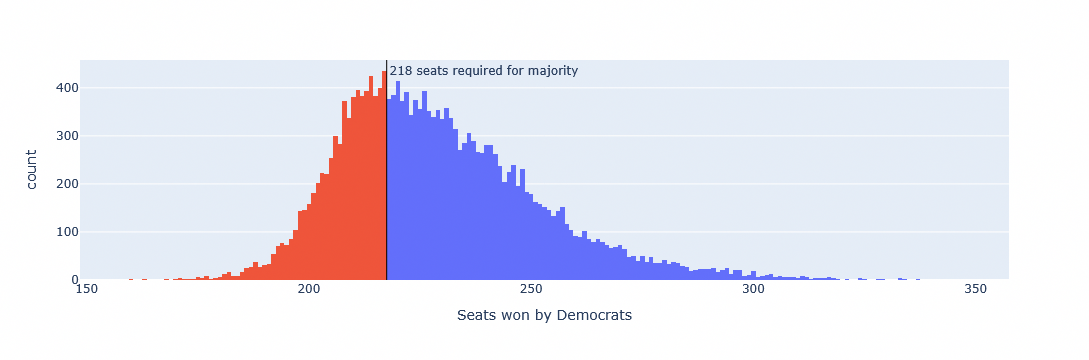

In [42]:
sims_hist = px.histogram(seat_sims, x='seats', nbins=np.unique(seat_sims['seats']).shape[0]*2, color='winner', 
                         labels={'seats':'Seats won by Democrats', 'winner': 'Winner'})
sims_hist.update_traces(showlegend=False)
sims_hist.add_vline(x=217.5, line_width=1, line_color='black', annotation_text='218 seats required for majority', 
                    annotation_position='top right')
sims_hist

In [43]:
# posterior prediction
post = pyreadr.read_r('model_output/labeled_posterior.RDS')[None]
post_untransp = post.copy()

In [44]:
post = post.T
post.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,...,19950,19951,19952,19953,19954,19955,19956,19957,19958,19959,19960,19961,19962,19963,19964,19965,19966,19967,19968,19969,19970,19971,19972,19973,19974,19975,19976,19977,19978,19979,19980,19981,19982,19983,19984,19985,19986,19987,19988,19989,19990,19991,19992,19993,19994,19995,19996,19997,19998,19999
AK-AL,-0.984544,-7.504496,-5.699124,-4.189268,-5.222294,-3.522391,-3.383522,0.445218,-11.663609,-1.625920,-9.695272,-4.287766,-8.251376,-5.069449,-0.726122,-5.192466,-5.903052,-6.462240,-3.308046,-5.348992,-6.629828,-0.923956,-4.916505,-7.665092,-0.514107,-6.799346,-6.388505,-1.650082,-9.065532,-6.591707,-4.779353,-5.930997,-5.694842,-6.029276,-4.816862,-5.944134,-3.892810,-6.776174,-7.272349,-5.840917,-2.327180,-10.909740,2.633624,-4.088661,-7.768834,-0.732597,-8.736128,-1.811622,-5.422347,-5.676120,...,-11.736231,-2.284475,-6.142229,-3.002164,-4.799463,-12.310144,0.376130,-9.766571,-1.307235,-4.856672,-8.909353,0.207413,-6.933688,-0.872457,-8.166370,-2.688388,-6.437617,-7.287599,3.346351,-13.586412,3.970634,-12.160208,-0.804653,-6.335522,-5.703819,-7.487345,-6.409670,-8.832446,-7.218592,-4.366559,-6.709395,-10.693061,-2.760850,-8.109307,-2.768917,-6.603715,-5.378433,-8.862218,0.642322,-12.935742,1.095124,-3.756160,-3.251615,-1.131383,-5.592993,-5.701402,-3.260990,-5.198817,-4.185060,-3.065269
AL-01,-10.994895,-16.742969,-16.720324,-13.663965,-14.270103,-16.648700,-17.977817,-8.930236,-18.271171,-9.334238,-14.337079,-12.571957,-20.479104,-15.599200,-11.662178,-12.393121,-13.134125,-14.418233,-16.391767,-10.720931,-15.971105,-7.360665,-12.761015,-16.346936,-8.901525,-16.214885,-15.301549,-9.007911,-15.854877,-17.195140,-13.377759,-14.728277,-16.508751,-13.848028,-11.225617,-15.572959,-14.688842,-16.297065,-16.136051,-14.692665,-13.547186,-17.886168,-11.677505,-13.090125,-18.839085,-12.372765,-15.419381,-10.340040,-11.992682,-18.069113,...,-20.651504,-11.646976,-13.964222,-15.383450,-14.832928,-21.978443,-5.969412,-16.754056,-10.351967,-9.408178,-14.300512,-11.680193,-16.054477,-12.437282,-18.083762,-8.774270,-14.691122,-14.998823,-11.189282,-17.778934,-8.196988,-19.081530,-13.487947,-16.229921,-13.268278,-16.482532,-13.963305,-18.074799,-12.258566,-12.337000,-18.722893,-17.626846,-14.294562,-14.122704,-11.402441,-13.357045,-14.299295,-19.216464,-8.697617,-15.781604,-9.727345,-10.490649,-13.464952,-12.781230,-16.610802,-16.286493,-19.828394,-11.552304,-15.004737,-11.269873
AL-02,-0.926699,-2.533514,-4.014344,-0.655686,-1.818979,-3.061015,-1.279647,-0.175407,-5.696177,-0.537736,-2.508146,-2.528264,-3.817001,-4.286383,3.513899,-0.627895,-6.993500,-3.348775,-4.086665,0.951026,-7.634458,2.023841,-7.661769,-2.386665,1.209367,-0.685588,-0.722290,-2.931207,-0.604320,-6.632446,0.292360,-5.468399,0.781924,-5.425584,3.827121,-4.471368,-2.913706,0.255282,-2.073189,-3.230756,-2.448248,-5.398192,-3.073018,-0.924433,-0.195059,-3.747523,-1.161739,-3.837402,-0.620924,-5.113414,...,-5.245270,-0.845871,-6.451232,0.568722,-3.880726,-5.713012,2.325454,-5.789383,-4.367413,1.696560,-7.501465,2.420190,-7.308272,0.921398,-8.174412,-0.021864,-3.155596,-0.174179,-0.033122,-0.050959,-0.327764,-5.710455,-5.112877,-1.419139,-0.305861,-1.342248,-2.468207,-2.114633,-4.415140,-1.865082,-4.186620,-7.138742,-2.240408,-2.784501,1.238655,-2.890215,0.317305,1.653916,-1.613831,-9.844061,2.045449,-2.396081,-2.301538,0.184998,-5.969739,2.585955,-4.029713,2.442935,0.266501,6.452916
AL-03,-15.941793,-23.431369,-23.381881,-21.836595,-21.642216,-19.831288,-22.319272,-17.081312,-25.693386,-18.726041,-24.764052,-21.453535,-25.677526,-26.799932,-17.628921,-18.072079,-23.851289,-21.237737,-20.071979,-19.182383,-23.471725,-17.557170,-21.348952,-24.010901,-15.924187,-20.409575,-22.101922,-19.094955,-20.881576,-21.608828,-18.776491,-24.426908,-19.594068,-22.048324,-17.134191,-23.871538,-19.762513,-18.586169,-21.454977,-22.790354,-20.499209,-

In [45]:
sim_corr = post_untransp.corr()

In [46]:
sim_corr

,AK-AL,AL-01,AL-02,AL-03,AL-04,AL-05,AL-06,AL-07,AR-01,AR-02,AR-03,AR-04,AZ-01,AZ-02,AZ-03,AZ-04,AZ-05,AZ-06,AZ-07,AZ-08,AZ-09,CA-01,CA-02,CA-03,CA-05,CA-06,CA-08,CA-09,CA-10,CA-13,CA-15,CA-16,CA-17,CA-18,CA-19,CA-20,CA-21,CA-22,CA-23,CA-24,CA-25,CA-26,CA-27,CA-28,CA-30,CA-31,CA-32,CA-33,CA-35,CA-36,...,TX-25,TX-26,TX-27,TX-28,TX-29,TX-30,TX-31,TX-32,TX-33,TX-34,TX-35,TX-36,TX-37,TX-38,UT-01,UT-02,UT-03,UT-04,VA-01,VA-02,VA-03,VA-04,VA-05,VA-06,VA-07,VA-08,VA-09,VA-10,VA-11,VT-AL,WA-01,WA-02,WA-03,WA-04,WA-05,WA-06,WA-07,WA-08,WA-09,WA-10,WI-01,WI-03,WI-04,WI-05,WI-06,WI-07,WI-08,WV-01,WV-02,WY-AL
AK-AL,1.000000,0.719602,0.482378,0.735232,0.728449,0.721732,0.733522,0.506695,0.735050,0.740918,0.739081,0.738960,0.494949,0.494050,0.496160,0.512731,0.701051,0.721886,0.721513,0.720032,0.740643,0.702404,0.512130,0.516753,0.741673,0.733252,0.575641,0.510018,0.519053,0.515587,0.501188,0.699256,0.564760,0.512570,0.504626,0.703566,0.512807,0.741146,0.729043,0.517603,0.521931,0.704253,0.486281,0.517818,0.489990,0.528340,0.555437,0.516284,0.567419,0.517602,...,0.734237,0.718933,0.550313,0.510154,0.511040,0.702654,0.737669,0.702207,0.542087,0.514020,0.699117,0.529465,0.496848,0.487546,0.502900,0.729470,0.716719,0.724341,0.744651,0.550547,0.513175,0.484013,0.718450,0.733897,0.499092,0.517648,0.737379,0.492362,0.700189,0.532809,0.515515,0.518436,0.493559,0.702559,0.546633,0.491919,0.506710,0.512677,0.574991,0.494708,0.733763,0.553010,0.578397,0.729331,0.741780,0.704442,0.714448,0.727089,0.713618,0.700766
AL-01,0.719602,1.000000,0.491707,0.744867,0.735521,0.726571,0.739209,0.511436,0.737274,0.745575,0.736883,0.743056,0.496116,0.495825,0.500544,0.515100,0.705503,0.724379,0.723858,0.722376,0.743902,0.702462,0.517524,0.524056,0.746434,0.733808,0.575770,0.515059,0.524536,0.524846,0.503621,0.703614,0.574191,0.511529,0.514835,0.707008,0.513920,0.741794,0.733369,0.520439,0.522789,0.699793,0.502410,0.519081,0.492110,0.539301,0.560699,0.520706,0.571827,0.522215,...,0.739332,0.722256,0.555996,0.515577,0.518321,0.701218,0.741399,0.706987,0.541078,0.516945,0.704827,0.538389,0.501049,0.495110,0.500872,0.728874,0.714474,0.726892,0.744349,0.552916,0.512636,0.488688,0.720140,0.736432,0.498491,0.520504,0.743210,0.496955,0.701075,0.532228,0.518340,0.521885,0.500752,0.707415,0.549203,0.497849,0.510748,0.512606,0.582154,0.501700,0.737349,0.557331,0.583717,0.734099,0.743151,0.704352,0.723979,0.735205,0.717239,0.706612
AL-02,0.482378,0.491707,1.000000,0.505956,0.501227,0.488807,0.503308,0.699005,0.498346,0.503820,0.498608,0.505629,0.685335,0.675374,0.680328,0.696008,0.647964,0.492657,0.490268,0.490755,0.500425,0.637002,0.699939,0.712222,0.506665,0.500896,0.584856,0.704661,0.711847,0.517400,0.676159,0.643909,0.578924,0.702940,0.700434,0.645735,0.706035,0.500744,0.503248,0.706087,0.710546,0.646096,0.677487,0.706937,0.676111,0.540967,0.566112,0.711214,0.583577,0.707049,...,0.499339,0.486322,0.560723,0.700996,0.702868,0.638973,0.503909,0.646285,0.556271,0.702087,0.643815,0.542767,0.689154,0.682483,0.687605,0.493118,0.491128,0.496748,0.500682,0.555426,0.700568,0.675134,0.484492,0.503497,0.675769,0.708447,0.500226,0.671476,0.644159,0.540755,0.705548,0.709311,0.685962,0.642647,0.547292,0.674649,0.698013,0.698626,0.587270,0.689763,0.504282,0.557547,0.586843,0.500529,0.503501,0.646683,0.489986,0.502132,0.482398,0.643787
AL-03,0.735232,0.744867,0.505956,1.000000,0.761389,0.745101,0.767590,0.528335,0.757574,0.763515,0.755729,0.759315,0.509272,0.511971,0.509893,0.524492,0.724914,0.743745,0.744107,0.741141,0.760524,0.722916,0.527434,0.536665,0.761248,0.756053,0.591636,0.528722,0.535847,0.533650,0.517609,0.721947,0.588273,0.528962,0.523642,0.725230,0.529440,0.761276,0.755844,0.534906,0.534354,0.723706,0.511066,0.532893,0.505264,0.552019,0.575555,0.531478,0.592816,0.536938,...,0.762199,0.745111,0.572763,0.532568,0.532224,0.723458,0.761197,0.728006,0.563277,0.528686,0.725167,0.552342,0.517256,0.508419,0.515553,0.752004,0.741585,0.748499,0.768343,0.571696,0.525530,0.505070,0.73641

In [47]:
post.shape

(422, 20000)

In [48]:
def get_tipping_point(sim):
    """
    :param sim: Series representing one posterior draw or "simulation"
    :type sim: pd.Series
    """
    seats_won_dem = np.sum(sim > 0)
    if seats_won_dem >= 218 - dem_uncont.shape[0]: # Democrats win House in this draw
        sim = sim.sort_values(ascending=True)
        won_seats = sim[sim > 0]
        seat_margin = seats_won_dem - (218 - dem_uncont.shape[0])
    else: # Republicans win House in this draw
        sim = sim.sort_values(ascending=False)
        won_seats = sim[sim < 0]
        seat_margin = (435 - seats_won_dem) - (218 - rep_uncont.shape[0])
    return won_seats.iloc[seat_margin - 1], won_seats.index[seat_margin - 1]

In [49]:
tipping_points = np.array([]) # tipping point for *each sim*

for i in tqdm(range(post.shape[1])):
    sim = post.iloc[:, i]
    _, tp_seat = get_tipping_point(sim)
    tipping_points = np.append(tipping_points, tp_seat)

tipping_points

100%|███████████████████████████████████████████████████████████████████████████| 20000/20000 [00:28<00:00, 713.98it/s]


array(['MI-04', 'MI-04', 'MD-04', ..., 'OH-01', 'CO-08', 'KY-06'],
      shape=(20000,), dtype='<U32')

In [50]:
data = pd.read_csv('../../model_output/house_predictions.csv')
data.head()

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-6.408975,0,1,0.000000,0.000000,0.000000,0.000000,Pacific,2026,0.0,0.0,0.0,2,200,1,975.656077,0.000000,0.000000,0.000000,-6.501630,-18.764506,-1,-37.529012,44.972806,3.555839,7.835,1,37.882058,51.905149
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-6.408975,0,0,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,101,1,122.699498,0.000000,0.000000,0.000000,-28.465308,-38.923019,0,-77.846039,36.026288,3.550855,0.010,2,29.060127,43.059523
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",490903.40,1130104.85,1621008.25,30.283831,69.716169,Alabama,AL-02,53.493739,2.691740,1.032138,0.183181,40.524512,16.170153,-6.640350,-6.482160,-6.521708,56.333429,42.767786,0.987401,-6.408975,1,0,45.599529,0.339529,45.799765,0.339529,East South Central,2026,0.0,0.0,0.0,1,102,1,917.110424,0.339529,0.582692,0.200235,-6.634441,-19.716169,1,-39.432338,47.892934,3.473518,26.845,3,41.080159,54.790085
3,3,AL-03,Lee McInnis,Mike Rogers,False,True,AL,3,"MCINNIS, VICTOR LEE","ROGERS, MICHAEL",60787.05,1356433.59,1417220.64,4.289173,95.710827,Alabama,AL-03,74.925713,2.047228,0.853803,0.164703,19.752354,15.301623,-22.977818,-22.768849,-22.821092,48.894607,26.481097,0.987401,-6.408975,0,1,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,103,1,18.397008,0.000000,0.000000,0.000000,-39.233209,-45.710827,-1,-91.421653,29.412819,3.447258,0.000,4,22.667241,36.179962
4,4,AL-04,Amanda Pusczek,Robert Aderholt,False,True,AL,4,"PUSCZEK, AMANDA NOELLE","ADERHOLT, ROBERT B. REP.",15462.00,523823.01,539285.01,2.867130,97.132870,Alabama,AL-04,86.997080,3.646458,0.489492,0.174054,6.737716,13.622184,-33.634273,-32.744762,-32.967139,33.245792,16.505184,0.987401,-6.408975,0,1,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,104,2,8.220432,0.000000,0.000000,0.000000,-59.525304,-47.132870,-1,-94.265741,19.686836,3.501842,0.000,5,12.831393,26.558872


In [51]:
data['tipping_point_prob'] = data['cd'].map(lambda x: np.mean(tipping_points == x) * 100)
data.head()

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-6.408975,0,1,0.000000,0.000000,0.000000,0.000000,Pacific,2026,0.0,0.0,0.0,2,200,1,975.656077,0.000000,0.000000,0.000000,-6.501630,-18.764506,-1,-37.529012,44.972806,3.555839,7.835,1,37.882058,51.905149,0.065
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-6.408975,0,0,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,101,1,122.699498,0.000000,0.000000,0.000000,-28.465308,-38.923019,0,-77.846039,36.026288,3.550855,0.010,2,29.060127,43.059523,0.000
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",490903.40,1130104.85,1621008.25,30.283831,69.716169,Alabama,AL-02,53.493739,2.691740,1.032138,0.183181,40.524512,16.170153,-6.640350,-6.482160,-6.521708,56.333429,42.767786,0.987401,-6.408975,1,0,45.599529,0.339529,45.799765,0.339529,East South Central,2026,0.0,0.0,0.0,1,102,1,917.110424,0.339529,0.582692,0.200235,-6.634441,-19.716169,1,-39.432338,47.892934,3.473518,26.845,3,41.080159,54.790085,1.265
3,3,AL-03,Lee McInnis,Mike Rogers,False,True,AL,3,"MCINNIS, VICTOR LEE","ROGERS, MICHAEL",60787.05,1356433.59,1417220.64,4.289173,95.710827,Alabama,AL-03,74.925713,2.047228,0.853803,0.164703,19.752354,15.301623,-22.977818,-22.768849,-22.821092,48.894607,26.481097,0.987401,-6.408975,0,1,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,103,1,18.397008,0.000000,0.000000,0.000000,-39.233209,-45.710827,-1,-91.421653,29.412819,3.447258,0.000,4,22.667241,36.179962,0.000
4,4,AL-04,Amanda Pusczek,Robert Aderholt,False,True,AL,4,"PUSCZEK, AMANDA NOELLE","ADERHOLT, ROBERT B. REP.",15462.00,523823.01,539285.01,2.867130,97.132870,Alabama,AL-04,86.997080,3.646458,0.489492,0.174054,6.737716,13.622184,-33.634273,-32.744762,-32.967139,33.245792,16.505184,0.987401,-6.408975,0,1,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,104,2,8.220432,0.000000,0.000000,0.000000,-59.525304,-47.132870,-1,-94.265741,19.686836,3.501842,0.000,5,12.831393,26.558872,0.000


In [52]:
data.sort_values('tipping_point_prob', ascending=False).head(10)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob
197,197,MI-10,Christina Hines,Mike Bouchard,False,False,MI,10,"HINES, CHRISTINA","BOUCHARD, MICHAEL",1135198.13,1290223.21,2425421.34,46.804162,53.195838,Michigan,MI-10,76.551128,2.316124,5.150984,0.123322,13.269372,29.340000,-2.765891,-2.592362,-2.635744,99.999226,46.657584,0.987401,-6.408975,0,0,45.000000,0.473498,45.000000,0.473498,East North Central,2026,0.0,0.000000,0.000000,26,2610,0,2190.629568,0.473498,0.688112,-1.460326e-07,1.137487,-3.195838,0,-6.391676,50.271600,3.611367,53.090,198,43.214053,57.334224,3.260
233,233,NC-11,Jamie Ager,Jennifer Balkcom,False,False,NC,11,"AGER, JAMIE",no_match,2799701.44,0.00,2799701.44,100.000000,0.000000,North Carolina,NC-11,88.740422,3.902084,0.797632,1.120840,3.305854,24.807640,-7.843347,-4.057125,-5.003681,49.294326,45.192821,0.987401,-6.408975,0,0,0.000000,0.000000,0.000000,0.000000,South Atlantic,2026,0.0,0.000000,0.000000,37,3711,2,10000.000000,0.000000,0.000000,0.000000e+00,-3.598386,50.000000,0,100.000000,50.565728,3.612850,56.400,234,43.439789,57.683526,2.830
37,37,CA-22,Randy Villegas,David Valadao,False,True,CA,22,"VILLEGAS, RANDY","VALADAO, DAVID",2396295.54,1423592.37,3819887.91,62.732090,37.267910,California,CA-22,22.131732,64.469110,4.924433,0.538078,6.308791,6.196120,6.443675,-0.178428,1.477097,85.545753,49.071518,0.987401,-6.408975,0,1,48.000000,0.082381,44.000000,0.082381,Pacific,2026,0.0,0.000000,0.000000,6,622,5,3935.315176,0.082381,0.287021,-4.000000e+00,9.363169,12.732090,-1,25.464181,50.607603,3.458861,57.165,38,43.832269,57.472714,2.730
194,194,MI-07,William Lawrence,Tom Barrett,False,True,MI,7,"LAWRENCE, WILLIAM","BARRETT, THOMAS MORE",1065694.20,3350486.21,4416180.41,24.131582,75.868418,Michigan,MI-07,85.239895,4.803904,1.944855,0.170025,5.279273,36.270000,-2.003691,0.098125,-0.427329,68.756305,49.348071,0.987401,-6.408975,0,1,48.971702,0.574397,46.971702,0.574397,East North Central,2026,0.0,0.000000,0.000000,26,2607,2,582.333253,0.574397,0.757890,-2.000000e+00,5.554317,-25.868418,-1,-51.736836,50.500204,3.517777,56.035,195,43.546965,57.332255,2.700
187,187,ME-02,Matt Dunlap,Paul LePage,False,False,ME,2,"DUNLAP, MATT","LEPAGE, PAUL",1181075.25,1418549.45,2599624.70,45.432529,54.567471,Maine,ME-02,94.623805,1.542589,0.598455,0.552005,0.848532,26.920000,-5.410176,-3.867301,-4.253020,26.830060,45.382645,0.987401,-6.408975,0,0,48.971709,0.205248,48.006269,0.205248,New England,2026,0.0,0.252840,-0.252840,23,2302,2,2064.114706,0.205248,0.453044,-9.654400e-01,-2.097065,-4.567471,0,-9.134942,49.621404,3.613961,45.815,188,42.561536,56.773553,2.695
318,318,PA-07,Bob Brooks,Ryan Mackenzie,False,True,PA,7,"BROOKS, BOB","MACKENZIE, RYAN EDWARD",1942165.53,1493241.01,3435406.54,56.533790,43.466210,Pennsylvania,PA-07,75.458946,15.481046,2.435986,0.030199,4.952274,31.050000,-1.956264,-0.869379,-1.141100,81.633883,48.380567,0.987401,-6.408975,0,1,47.000000,0.125591,43.000000,0.125591,Mid-Atlantic,2026,0.0,0.000000,0.000000,42,4207,0,3196.069448,0.125591,0.354388,-4.000000e+00,4.126774,6.533790,-1,13.067581,50.302251,3.513933,53.285,319,43.443511,57.179645,2.650
98,98,FL-22,Pia Dandiya,Casey Askar,False,False,FL,22,"DANDIYA, PIA","ASKAR, CASEY",1965051.29,57760.00,2022811.29,97.144568,2.855432,Florida,FL-22,53.931205,26.984941,3.703933,0.199203,13.186062,27.190634,-0.817400,-4.551960,-3.618320,91.180168,44

In [53]:
def get_rating(dem_chance):
    if dem_chance > 100:
        raise ValueError('Invalid win chance.')
    if dem_chance > 95:
        return 'Safe D'
    elif dem_chance >= 90:
        return 'Very Likely D'
    elif dem_chance >= 75:
        return 'Likely D'
    elif dem_chance >= 65:
        return 'Lean D'
    elif dem_chance >= 60:
        return 'Tilt D'
    elif dem_chance >= 40:
        return 'Tossup'
    elif dem_chance >= 35:
        return 'Tilt R'
    elif dem_chance >= 25:
        return 'Lean R'
    elif dem_chance >= 10:
        return 'Likely R'
    elif dem_chance >= 5:
        return 'Very Likely R'
    else:
        return 'Safe R'

def get_matchup(dem_cand, rep_cand, dem_inc_any, rep_inc_any):
    indie_d = ['Bill Hill']
    indie_r = ['Kevin Kiley']
    
    if dem_cand in indie_d:
        dem_lab = dem_cand + f'{'*' if dem_inc_any == True else ''}' + ' (I)'
        dem_color = '#792ba6'
    else:
        dem_lab = dem_cand + f'{'*' if dem_inc_any == True else ''}' + ' (D)'
        dem_color = '#366bbf'
    
    if rep_cand in indie_r:
        rep_lab = rep_cand + f'{'*' if rep_inc_any == True else ''}' + ' (I)'
        rep_color = '#792ba6'
    else:
        rep_lab = rep_cand + f'{'*' if rep_inc_any == True else ''}' + ' (R)'
        rep_color = '#e63929'

    return f'<b style="color:{dem_color};">' + dem_lab + f'</b> vs <b style="color:{rep_color};">' + rep_lab + '</b>'

In [54]:
data['rating'] = data['chance'].map(lambda x: get_rating(x))
for party in ['dem', 'rep']:
    data[f'{party}_cand'] = data[f'{party}_cand'].map(lambda x: 'TBD' if x[:3] == 'TBD' else x)
data['matchup'] = data[['dem_cand', 'rep_cand', 'dem_inc_any', 'rep_inc_any']].apply(lambda x: get_matchup(x['dem_cand'], x['rep_cand'],
                                                                                                          x['dem_inc_any'], x['rep_inc_any']), axis=1)
data.head()

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-6.408975,0,1,0.000000,0.000000,0.000000,0.000000,Pacific,2026,0.0,0.0,0.0,2,200,1,975.656077,0.000000,0.000000,0.000000,-6.501630,-18.764506,-1,-37.529012,44.972806,3.555839,7.835,1,37.882058,51.905149,0.065,Very Likely R,"<b style=""color:#792ba6;"">Bill Hill (I)</b> vs..."
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-6.408975,0,0,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,101,1,122.699498,0.000000,0.000000,0.000000,-28.465308,-38.923019,0,-77.846039,36.026288,3.550855,0.010,2,29.060127,43.059523,0.000,Safe R,"<b style=""color:#366bbf;"">Clyde Jones Jr. (D)<..."
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",490903.40,1130104.85,1621008.25,30.283831,69.716169,Alabama,AL-02,53.493739,2.691740,1.032138,0.183181,40.524512,16.170153,-6.640350,-6.482160,-6.521708,56.333429,42.767786,0.987401,-6.408975,1,0,45.599529,0.339529,45.799765,0.339529,East South Central,2026,0.0,0.0,0.0,1,102,1,917.110424,0.339529,0.582692,0.200235,-6.634441,-19.716169,1,-39.432338,47.892934,3.473518,26.845,3,41.080159,54.790085,1.265,Lean R,"<b style=""color:#366bbf;"">Shomari Figures* (D)..."
3,3,AL-03,Lee McInnis,Mike Rogers,False,True,AL,3,"MCINNIS, VICTOR LEE","ROGERS, MICHAEL",60787.05,1356433.59,1417220.64,4.289173,95.710827,Alabama,AL-03,74.925713,2.047228,0.853803,0.164703,19.752354,15.301623,-22.977818,-22.768849,-22.821092,48.894607,26.481097,0.987401,-6.408975,0,1,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,103,1,18.397008,0.000000,0.000000,0.000000,-39.233209,-45.710827,-1,-91.421653,29.412819,3.447258,0.000,4,22.667241,36.179962,0.000,Safe R,"<b style=""color:#366bbf;"">Lee McInnis (D)</b> ..."
4,4,AL-04,Amanda Pusczek,Robert Aderholt,False,True,AL,4,"PUSCZEK, AMANDA NOELLE","ADERHOLT, ROBERT B. REP.",15462.00,523823.01,539285.01,2.867130,97.132870,Alabama,AL-04,86.997080,3.646458,0.489492,0.174054,6.737716,13.622184,-33.634273,-32.744762,-32.967139,33.245792,16.505184,0.987401,-6.408975,0,1,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,104,2,8.220432,0.000000,0.000000,0.000000,-59.525304,-47.132870,-1,-94.265741,19.686836,3.501842,0.000,5,12.831393,26.558872,0.000,Safe R,"<b style=""color:#366bbf;"">Amanda Pusczek (D)</..."


In [55]:
data['projected_winner'] = data['chance'].map(lambda x: '(D)' if x > 50 else '(R)')
data.head(3)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-6.408975,0,1,0.000000,0.000000,0.000000,0.000000,Pacific,2026,0.0,0.0,0.0,2,200,1,975.656077,0.000000,0.000000,0.000000,-6.501630,-18.764506,-1,-37.529012,44.972806,3.555839,7.835,1,37.882058,51.905149,0.065,Very Likely R,"<b style=""color:#792ba6;"">Bill Hill (I)</b> vs...",(R)
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-6.408975,0,0,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,101,1,122.699498,0.000000,0.000000,0.000000,-28.465308,-38.923019,0,-77.846039,36.026288,3.550855,0.010,2,29.060127,43.059523,0.000,Safe R,"<b style=""color:#366bbf;"">Clyde Jones Jr. (D)<...",(R)
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",490903.40,1130104.85,1621008.25,30.283831,69.716169,Alabama,AL-02,53.493739,2.691740,1.032138,0.183181,40.524512,16.170153,-6.640350,-6.482160,-6.521708,56.333429,42.767786,0.987401,-6.408975,1,0,45.599529,0.339529,45.799765,0.339529,East South Central,2026,0.0,0.0,0.0,1,102,1,917.110424,0.339529,0.582692,0.200235,-6.634441,-19.716169,1,-39.432338,47.892934,3.473518,26.845,3,41.080159,54.790085,1.265,Lean R,"<b style=""color:#366bbf;"">Shomari Figures* (D)...",(R)


In [56]:
pvi_24 = pd.read_csv('../../transformed/pvi/past_pres_results_by24dist.csv')
data = pd.merge(left=data, right=pvi_24[['district', 'party']], left_on='cd', right_on='district')
data = data.rename({'party': 'curr_party'}, axis=1)
data['hold'] = data['projected_winner'] ==  data['curr_party']
data['flip'] = data['hold'].map(lambda x: not x)
data['flip_indic'] = data['flip'].map(lambda x: 'Flip' if x else '')
#data['flip'] = data['flip'].map(lambda x: 'Yes' if x else 'No')
data.head(2)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district_x,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,district_y,curr_party,hold,flip,flip_indic
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-6.408975,0,1,0.0,0.0,0.0,0.0,Pacific,2026,0.0,0.0,0.0,2,200,1,975.656077,0.0,0.0,0.0,-6.501630,-18.764506,-1,-37.529012,44.972806,3.555839,7.835,1,37.882058,51.905149,0.065,Very Likely R,"<b style=""color:#792ba6;"">Bill Hill (I)</b> vs...",(R),AK-AL,(R),True,False,
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-6.408975,0,0,0.0,0.0,0.0,0.0,East South Central,2026,0.0,0.0,0.0,1,101,1,122.699498,0.0,0.0,0.0,-28.465308,-38.923019,0,-77.846039,36.026288,3.550855,0.010,2,29.060127,43.059523,0.000,Safe R,"<b style=""color:#366bbf;"">Clyde Jones Jr. (D)<...",(R),AL-01,(R),True,False,


In [57]:
data['projected_2p_margin'] = data['y_pred'].map(lambda y_pred: f'D+{y_pred - (100-y_pred):.1f}' if y_pred > 50 else f'R+{(100-y_pred) - y_pred:.1f}')
data.head(3)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district_x,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,district_y,curr_party,hold,flip,flip_indic,projected_2p_margin
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-6.408975,0,1,0.000000,0.000000,0.000000,0.000000,Pacific,2026,0.0,0.0,0.0,2,200,1,975.656077,0.000000,0.000000,0.000000,-6.501630,-18.764506,-1,-37.529012,44.972806,3.555839,7.835,1,37.882058,51.905149,0.065,Very Likely R,"<b style=""color:#792ba6;"">Bill Hill (I)</b> vs...",(R),AK-AL,(R),True,False,,R+10.1
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-6.408975,0,0,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,101,1,122.699498,0.000000,0.000000,0.000000,-28.465308,-38.923019,0,-77.846039,36.026288,3.550855,0.010,2,29.060127,43.059523,0.000,Safe R,"<b style=""color:#366bbf;"">Clyde Jones Jr. (D)<...",(R),AL-01,(R),True,False,,R+27.9
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",490903.40,1130104.85,1621008.25,30.283831,69.716169,Alabama,AL-02,53.493739,2.691740,1.032138,0.183181,40.524512,16.170153,-6.640350,-6.482160,-6.521708,56.333429,42.767786,0.987401,-6.408975,1,0,45.599529,0.339529,45.799765,0.339529,East South Central,2026,0.0,0.0,0.0,1,102,1,917.110424,0.339529,0.582692,0.200235,-6.634441,-19.716169,1,-39.432338,47.892934,3.473518,26.845,3,41.080159,54.790085,1.265,Lean R,"<b style=""color:#366bbf;"">Shomari Figures* (D)...",(R),AL-02,(D),False,True,Flip,R+4.2


In [58]:
data['rep_chance'] = data['chance'].map(lambda x: 100 - x)
data['rounded_dem_chance'] = data['chance'].map(lambda x: np.round(x, 1))
data['rounded_rep_chance'] = data['rep_chance'].map(lambda x: np.round(x, 1))
data['disp_dem_chance'] = data['rounded_dem_chance'].map(lambda x: '>99%' if x > 99 else ('<1%' if x < 1 else str(x) + '%'))
data['disp_rep_chance'] = data['rounded_rep_chance'].map(lambda x: '>99%' if x > 99 else ('<1%' if x < 1 else str(x) + '%'))
data.head(3)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district_x,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,district_y,curr_party,hold,flip,flip_indic,projected_2p_margin,rep_chance,rounded_dem_chance,rounded_rep_chance,disp_dem_chance,disp_rep_chance
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-6.408975,0,1,0.000000,0.000000,0.000000,0.000000,Pacific,2026,0.0,0.0,0.0,2,200,1,975.656077,0.000000,0.000000,0.000000,-6.501630,-18.764506,-1,-37.529012,44.972806,3.555839,7.835,1,37.882058,51.905149,0.065,Very Likely R,"<b style=""color:#792ba6;"">Bill Hill (I)</b> vs...",(R),AK-AL,(R),True,False,,R+10.1,92.165,7.8,92.2,7.8%,92.2%
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-6.408975,0,0,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,101,1,122.699498,0.000000,0.000000,0.000000,-28.465308,-38.923019,0,-77.846039,36.026288,3.550855,0.010,2,29.060127,43.059523,0.000,Safe R,"<b style=""color:#366bbf;"">Clyde Jones Jr. (D)<...",(R),AL-01,(R),True,False,,R+27.9,99.990,0.0,100.0,<1%,>99%
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",490903.40,1130104.85,1621008.25,30.283831,69.716169,Alabama,AL-02,53.493739,2.691740,1.032138,0.183181,40.524512,16.170153,-6.640350,-6.482160,-6.521708,56.333429,42.767786,0.987401,-6.408975,1,0,45.599529,0.339529,45.799765,0.339529,East South Central,2026,0.0,0.0,0.0,1,102,1,917.110424,0.339529,0.582692,0.200235,-6.634441,-19.716169,1,-39.432338,47.892934,3.473518,26.845,3,41.080159,54.790085,1.265,Lean R,"<b style=""color:#366bbf;"">Shomari Figures* (D)...",(R),AL-02,(D),False,True,Flip,R+4.2,73.155,26.8,73.2,26.8%,73.2%


In [59]:
data['swing_24_to_26'] = data['y_pred'].astype(float).map(lambda x: x - (100 - x)) - data['dem_2p_24'].astype(float).map(lambda x: x - (100 - x))
data.head(3)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district_x,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,district_y,curr_party,hold,flip,flip_indic,projected_2p_margin,rep_chance,rounded_dem_chance,rounded_rep_chance,disp_dem_chance,disp_rep_chance,swing_24_to_26
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-6.408975,0,1,0.000000,0.000000,0.000000,0.000000,Pacific,2026,0.0,0.0,0.0,2,200,1,975.656077,0.000000,0.000000,0.000000,-6.501630,-18.764506,-1,-37.529012,44.972806,3.555839,7.835,1,37.882058,51.905149,0.065,Very Likely R,"<b style=""color:#792ba6;"">Bill Hill (I)</b> vs...",(R),AK-AL,(R),True,False,,R+10.1,92.165,7.8,92.2,7.8%,92.2%,3.638738
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-6.408975,0,0,0.000000,0.000000,0.000000,0.000000,East South Central,2026,0.0,0.0,0.0,1,101,1,122.699498,0.000000,0.000000,0.000000,-28.465308,-38.923019,0,-77.846039,36.026288,3.550855,0.010,2,29.060127,43.059523,0.000,Safe R,"<b style=""color:#366bbf;"">Clyde Jones Jr. (D)<...",(R),AL-01,(R),True,False,,R+27.9,99.990,0.0,100.0,<1%,>99%,8.397048
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",490903.40,1130104.85,1621008.25,30.283831,69.716169,Alabama,AL-02,53.493739,2.691740,1.032138,0.183181,40.524512,16.170153,-6.640350,-6.482160,-6.521708,56.333429,42.767786,0.987401,-6.408975,1,0,45.599529,0.339529,45.799765,0.339529,East South Central,2026,0.0,0.0,0.0,1,102,1,917.110424,0.339529,0.582692,0.200235,-6.634441,-19.716169,1,-39.432338,47.892934,3.473518,26.845,3,41.080159,54.790085,1.265,Lean R,"<b style=""color:#366bbf;"">Shomari Figures* (D)...",(R),AL-02,(D),False,True,Flip,R+4.2,73.155,26.8,73.2,26.8%,73.2%,10.250296


In [60]:
data['disp_24_to_26_swing'] = data['swing_24_to_26'].map(lambda x: f'D+{x:.1f}' if x > 0 else f'R+{abs(x):.1f}')
data.head(2)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,dem_funds,rep_funds,2p_funds,dem_funds_2p_pct,rep_funds_2p_pct,state,district_x,cvap_white_pct,cvap_hisp_pct,cvap_aapi_pct,cvap_natam_pct,cvap_black_pct,college,lean_20,lean_24,pvi,urban_pct,dem_2p_24,polarization,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_poll_avg,dem_effn,rep_poll_avg,rep_effn,census_region,year,dem_scandal_score,rep_scandal_score,net_scandal_score,fips,geoid,demo_cluster,dem_funds_2p_pct_sqrd,effn,sqrt_effn,poll_margin,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner,district_y,curr_party,hold,flip,flip_indic,projected_2p_margin,rep_chance,rounded_dem_chance,rounded_rep_chance,disp_dem_chance,disp_rep_chance,swing_24_to_26,disp_24_to_26_swing
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",1264611.09,2784023.76,4048634.85,31.235494,68.764506,Alaska,AK-00,64.463948,6.051383,6.481397,12.640423,3.077471,30.750000,-7.531684,-6.096509,-6.455302,64.899487,43.153437,0.987401,-6.408975,0,1,0.0,0.0,0.0,0.0,Pacific,2026,0.0,0.0,0.0,2,200,1,975.656077,0.0,0.0,0.0,-6.501630,-18.764506,-1,-37.529012,44.972806,3.555839,7.835,1,37.882058,51.905149,0.065,Very Likely R,"<b style=""color:#792ba6;"">Bill Hill (I)</b> vs...",(R),AK-AL,(R),True,False,,R+10.1,92.165,7.8,92.2,7.8%,92.2%,3.638738,D+3.6
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",83967.63,674069.54,758037.17,11.076981,88.923019,Alabama,AL-01,69.156017,2.677114,1.299003,0.469439,24.385648,17.996871,-17.482017,-17.422182,-17.437141,68.324941,31.827764,0.987401,-6.408975,0,0,0.0,0.0,0.0,0.0,East South Central,2026,0.0,0.0,0.0,1,101,1,122.699498,0.0,0.0,0.0,-28.465308,-38.923019,0,-77.846039,36.026288,3.550855,0.010,2,29.060127,43.059523,0.000,Safe R,"<b style=""color:#366bbf;"">Clyde Jones Jr. (D)<...",(R),AL-01,(R),True,False,,R+27.9,99.990,0.0,100.0,<1%,>99%,8.397048,D+8.4


In [61]:
data['geoid']

0       200
1       101
2       102
3       103
4       104
       ... 
417    5507
418    5508
419    5401
420    5402
421    5600
Name: geoid, Length: 422, dtype: int64

In [62]:
dem_uclen = dem_uncont.shape[0]
dem_uncont['rating'] = np.full(dem_uclen, 'Safe D')
dem_uncont['chance'] = np.full(dem_uclen, 100)
dem_uncont['y_pred'] = np.full(dem_uclen, 100)
dem_uncont['swing_24_to_26'] = np.full(dem_uclen, float('nan')) # Placeholder
dem_uncont['disp_24_to_26_swing'] = np.full(dem_uclen, float('nan')) # Placeholder
dem_uncont['disp_dem_chance'] = np.full(dem_uclen, '100%')
dem_uncont['disp_rep_chance'] = np.full(dem_uclen, '0%')
dem_uncont['projected_2p_margin'] = np.full(dem_uclen, 'D+100')
dem_uncont['flip_indic'] = np.full(dem_uclen, '')
dem_uncont = dem_uncont.drop(['Unnamed: 0'], axis=1)
dem_uncont['matchup'] = dem_uncont[['dem_cand', 'rep_cand', 'dem_inc_any', 'rep_inc_any']].apply(lambda x: get_matchup(x['dem_cand'], x['rep_cand'],
                                                                                                                      x['dem_inc_any'], x['rep_inc_any']), axis=1)
dem_uncont.head()

,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fips,geoid,rating,chance,y_pred,swing_24_to_26,disp_24_to_26_swing,disp_dem_chance,disp_rep_chance,projected_2p_margin,flip_indic,matchup
0,CA-04,Mike Thompson/Eric Jones,Not Contested,True,False,CA,4,6,604,Safe D,100,100,NaN,NaN,100%,0%,D+100,,"<b style=""color:#366bbf;"">Mike Thompson/Eric J..."
1,CA-07,Doris Matsui/Mai Vang,Not Contested,True,False,CA,7,6,607,Safe D,100,100,NaN,NaN,100%,0%,D+100,,"<b style=""color:#366bbf;"">Doris Matsui/Mai Van..."
2,CA-11,Scott Weiner/Connie Chan,Not Contested,False,False,CA,11,6,611,Safe D,100,100,NaN,NaN,100%,0%,D+100,,"<b style=""color:#366bbf;"">Scott Weiner/Connie ..."
3,CA-12,Lateefah Simon,Not Contested,True,False,CA,12,6,612,Safe D,100,100,NaN,NaN,100%,0%,D+100,,"<b style=""color:#366bbf;"">Lateefah Simon* (D)<..."
4,CA-14,Aisha Wahab/Melissa Hernandez,Not Contested,False,False,CA,14,6,614,Safe D,100,100,NaN,NaN,100%,0%,D+100,,"<b style=""color:#366bbf;"">Aisha Wahab/Melissa ..."


In [63]:
rep_uclen = rep_uncont.shape[0]
rep_uncont['rating'] = np.full(rep_uclen, 'Safe R')
rep_uncont['chance'] = np.full(rep_uclen, 0)
rep_uncont['y_pred'] = np.full(rep_uclen, 0)
rep_uncont['swing_24_to_26'] = np.full(rep_uclen, float('nan')) # Placeholder
rep_uncont['disp_24_to_26_swing'] = np.full(rep_uclen, float('nan')) # Placeholder
rep_uncont['disp_dem_chance'] = np.full(rep_uclen, '0%')
rep_uncont['disp_rep_chance'] = np.full(rep_uclen, '100%')
rep_uncont['projected_2p_margin'] = np.full(rep_uclen, 'R+100')
rep_uncont['flip_indic'] = np.full(rep_uclen, '')
rep_uncont = rep_uncont.drop(['Unnamed: 0'], axis=1)
rep_uncont['matchup'] = rep_uncont[['dem_cand', 'rep_cand', 'dem_inc_any', 'rep_inc_any']].apply(lambda x: get_matchup(x['dem_cand'], x['rep_cand'],
                                                                                                                       x['dem_inc_any'], x['rep_inc_any']), axis=1)
rep_uncont.head()

,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fips,geoid,rating,chance,y_pred,swing_24_to_26,disp_24_to_26_swing,disp_dem_chance,disp_rep_chance,projected_2p_margin,flip_indic,matchup
0,CA-40,Not Contested,Young Kim/Ken Calvert,False,True,CA,40,6,640,Safe R,0,0,NaN,NaN,0%,100%,R+100,,"<b style=""color:#366bbf;"">Not Contested (D)</b..."


In [64]:
incl_cols = ['cd', 'dem_cand', 'rep_cand', 'dem_inc_any', 'rep_inc_any', 'rating', 'chance', 'disp_dem_chance',
            'disp_rep_chance', 'projected_2p_margin', 'y_pred', 'flip_indic', 'geoid', 'matchup', 'swing_24_to_26', 'disp_24_to_26_swing']
disp_data = pd.concat([data[incl_cols], dem_uncont[incl_cols], rep_uncont[incl_cols]], axis=0)
disp_data.shape

(435, 16)

In [65]:
tab_data = data[['cd', 'dem_cand', 'rep_cand', 'rating', 'disp_dem_chance', 'disp_rep_chance', 'projected_2p_margin', 'disp_24_to_26_swing',
                 'tipping_point_prob']]
for party in ['dem', 'rep']:
    tab_data[f'disp_{party}_chance'] = tab_data[f'disp_{party}_chance'].map(lambda x: f'<p style="color:{'blue' if party == 'dem' else 'red'};">{x}</p>')
    tab_data[f'{party}_cand'] = tab_data[f'{party}_cand'].map(lambda x: f'{x} (Ind)' if x in ['Bill Hill', 'Kevin Kiley'] else x)
tab_data = tab_data.rename({
    'cd': 'District',
    'dem_cand': 'Democrat',
    'rep_cand': 'Republican',
    'rating': 'Rating',
    'disp_dem_chance': 'Dem Chance',
    'disp_rep_chance': 'Rep Chance',
    'projected_2p_margin': 'Projected Margin',
    'tipping_point_prob': 'Tipping Point Chance',
    'disp_24_to_26_swing': 'Swing from 2024 Pres'
}, axis=1)
tab_data.head()

,District,Democrat,Republican,Rating,Dem Chance,Rep Chance,Projected Margin,Swing from 2024 Pres,Tipping Point Chance
0,AK-AL,Bill Hill (Ind),Nick Begich,Very Likely R,"<p style=""color:blue;"">7.8%</p>","<p style=""color:red;"">92.2%</p>",R+10.1,D+3.6,0.065
1,AL-01,Clyde Jones Jr.,Jerry Carl,Safe R,"<p style=""color:blue;""><1%</p>","<p style=""color:red;"">>99%</p>",R+27.9,D+8.4,0.000
2,AL-02,Shomari Figures,Rhett Marques,Lean R,"<p style=""color:blue;"">26.8%</p>","<p style=""color:red;"">73.2%</p>",R+4.2,D+10.3,1.265
3,AL-03,Lee McInnis,Mike Rogers,Safe R,"<p style=""color:blue;""><1%</p>","<p style=""color:red;"">>99%</p>",R+41.2,D+5.9,0.000
4,AL-04,Amanda Pusczek,Robert Aderholt,Safe R,"<p style=""color:blue;""><1%</p>","<p style=""color:red;"">>99%</p>",R+60.6,D+6.4,0.000


In [66]:
data['rep_pred'] = data['y_pred'].map(lambda x: 100 - x)
data['projected_2p_margin_number'] = data['rep_pred'] - data['y_pred']
data['proj_seat_lean'] = data['projected_2p_margin_number'] - data['generic_ballot_avg']
sv_bias = float(data.sort_values('tipping_point_prob', ascending=False).reset_index().loc[0, 'proj_seat_lean']) # Seats-votes bias, + = R, - = D
sv_bias

5.86577366686145

In [67]:
topline_stats = pd.read_csv('display_data/topline_stats.csv')
if 'sv_bias' in topline_stats['vars'].values:
    topline_stats = topline_stats[topline_stats['vars'] != 'sv_bias']
topline_stats = pd.concat([topline_stats, pd.DataFrame({'vars': ['sv_bias'], 'x': sv_bias})], axis=0)
topline_stats.to_csv('display_data/topline_stats.csv')
topline_stats

,Unnamed: 0,vars,x
0,0.0,means_seats_tot,229.407000
1,1.0,chamber_win_chance,66.085000
0,NaN,sv_bias,5.865774


In [68]:
disp_data.to_csv('display_data/choropleth_display_data.csv')
tab_data.to_csv('display_data/table_display_data.csv')
data.to_csv('display_data/all_data.csv')